In [50]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [51]:
dataset = pd.read_csv("Salary.csv")
dataset.head(10)

,Age,Years of Experience,Salary
0,32,5.0,90000
1,28,3.0,65000
2,45,15.0,150000
3,36,7.0,60000
4,52,20.0,200000
5,29,2.0,55000
6,42,12.0,120000
7,31,4.0,80000
8,26,1.0,45000
9,38,10.0,110000


In [52]:
dataset.shape

(375, 3)

In [53]:
dataset.isnull().sum()

Age                    0
Years of Experience    0
Salary                 0
dtype: int64

In [54]:
dataset["Salary"].fillna(dataset["Salary"].mode()[0] , inplace = True)

/var/folders/2m/h337yr6d12v5rvz8gmlfz2s80000gn/T/ipykernel_39835/3239665714.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset["Salary"].fillna(dataset["Salary"].mode()[0] , inplace = True)


0       90000
1       65000
2      150000
3       60000
4      200000
        ...  
370     85000
371    170000
372     40000
373     90000
374    150000
Name: Salary, Length: 375, dtype: int64

In [55]:
dataset.isnull().sum()

Age                    0
Years of Experience    0
Salary                 0
dtype: int64

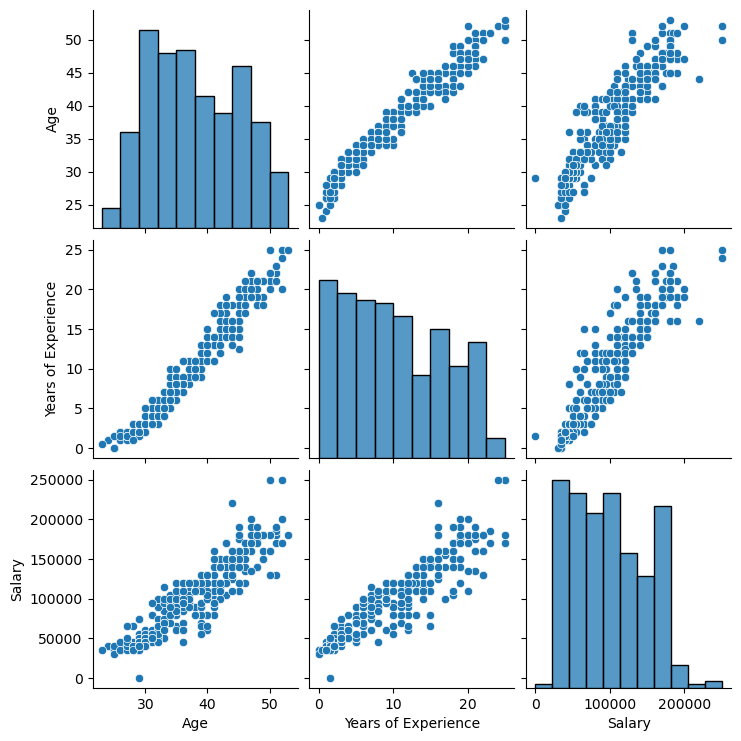

In [57]:
sns.pairplot(data = dataset)
plt.show()

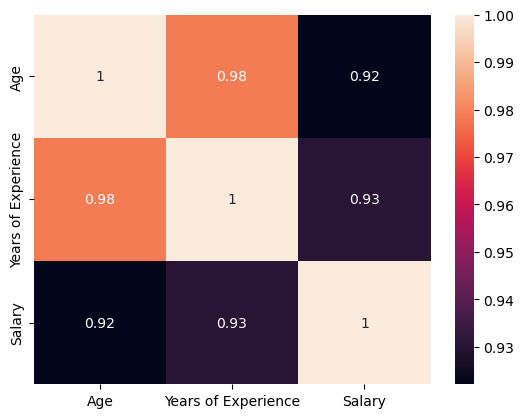

In [58]:
sns.heatmap(data = dataset.corr() , annot = True)
plt.show()

In [59]:
x = dataset.iloc[:,:-1]
y = dataset["Salary"]



In [60]:
x.ndim

2

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
 x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.25 , random_state=42)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lr = LinearRegression()

In [65]:
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
lr.score(x_test , y_test)*100

85.75668409649089

In [68]:
#y = m1x1 +m2x2 +c this is the algorithm 
#y_prd = 2267.71304581*AGE + 4545.46202533*Years of Experience + -30536.821918579502

In [71]:
lr.coef_

array([2267.71304581, 4545.46202533])

In [72]:
lr.intercept_

np.float64(-30536.821918579502)

In [74]:
lr.predict(x_test)

array([155596.29464434, 103358.60712109, 141969.94450208,  73838.19379076,
       144247.6934816 , 176035.81985773, 182848.99492886,  94287.75493787,
        53398.66857737,  94277.71900416, 123798.13233449, 176035.81985773,
        46585.49350624,  92010.00595835,  60211.8436485 , 141969.94450208,
        64757.30567383,  37509.62335616,  78383.65581609,  85196.83088722,
       101090.89407529,  94277.71900416, 144237.65754788,  67025.01871963,
        98823.18102948,  55676.41755689, 166954.9317408 ,  60221.87958221,
       148793.15550692, 153338.61753225,  46595.52943995, 126075.88131401,
        51130.95553156, 137424.48247675,  76115.94277028,  23893.30914761,
       171500.39376612,  46585.49350624,  37514.64132302,  57944.13060269,
        46585.49350624,  87464.54393303, 196485.38100484, 164677.18276128,
        42050.06741463, 141969.94450208, 101100.930009  ,  39782.35436882,
        44317.78046043,  42050.06741463, 103358.60712109,  82929.11784141,
        85196.83088722, 1